In [54]:
# import necessary libraries
import pandas as pd

#load dataset
df = pd.read_csv(r"C:\Users\ASUS\Downloads\customer_shopping_behavior.csv")

In [72]:
# Basic analysis
# Q1 Check first five rows, no.of rows and cols, data type, handle null values, duplicate values

df.head()

df.describe()

df.shape

df.dtypes

df.isnull().sum()
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

df.duplicated().sum()

In [182]:
# Intermediate Analysis

# Q1 Total revenue
df['Purchase Amount (USD)'].sum()

# Q2 Total number of purchase
df['Item Purchased'].value_counts().sum()

# Q3 Average review
df['Review Rating'].mean()

# Q4 Highest selling category
df['Category'].value_counts().sort_values(ascending = False)

# Q5 Number of unique category, location, payment method
df['Category'].nunique()

df['Payment Method'].nunique()

df['Location'].nunique()

In [183]:
# Advance analysis

#Q1 Which category has the highest number of revenue?
df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending = False)

#Q2 Which category has the highest average spending?
df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending = False)

#Q3 Which gender spends more?
df.groupby('Gender')['Purchase Amount (USD)'].sum().sort_values(ascending = False)

#Q4 Which category has the highest review rating?
df.groupby('Category')['Review Rating'].sum().sort_values(ascending = False)

#Q5 Which category generates the highest purchases?
df.groupby('Category')['Item Purchased'].sum().sort_values(ascending = False)

#Q6 What is the average order value per category?
df.groupby('Category')['Purchase Amount (USD)'].mean()

#Q7 Who are the top 10 spending customers?
df.groupby('Customer ID')['Purchase Amount (USD)'].sum().sort_values(ascending = False).head(10)

#Q8 Which shipping type is most used?
# df['Shipping Type'].value_counts().sort_values(ascending = False)

#Q9 Most popular payment method?
df['Payment Method'].value_counts().sort_values(ascending = False)

#Q10 Subscription vs non-subscription customer behavior
df.groupby('Subscription Status')['Purchase Amount (USD)'].sum().sort_values(ascending = False)

In [167]:
# Visualization
# import necessary libraries

import matplotlib.pyplot as plt
import seaborn as sns

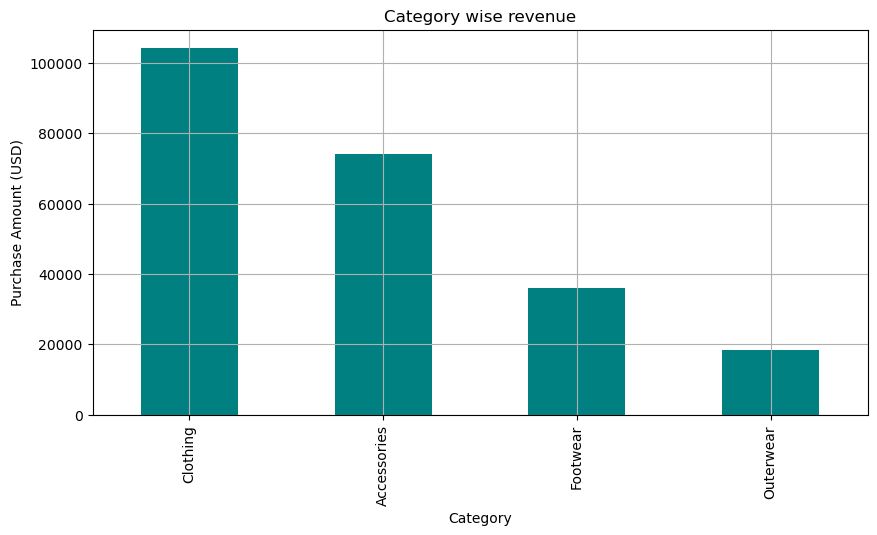

In [155]:
#Q1 Which category generates highest revenue?
highest_purchase = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending = False)
plt.figure()
highest_purchase.plot(kind = 'bar', color='teal', grid=True, figsize=(10,5))
plt.xlabel('Category')
plt.ylabel('Purchase Amount (USD)')
plt.title('Category wise revenue')
plt.show()

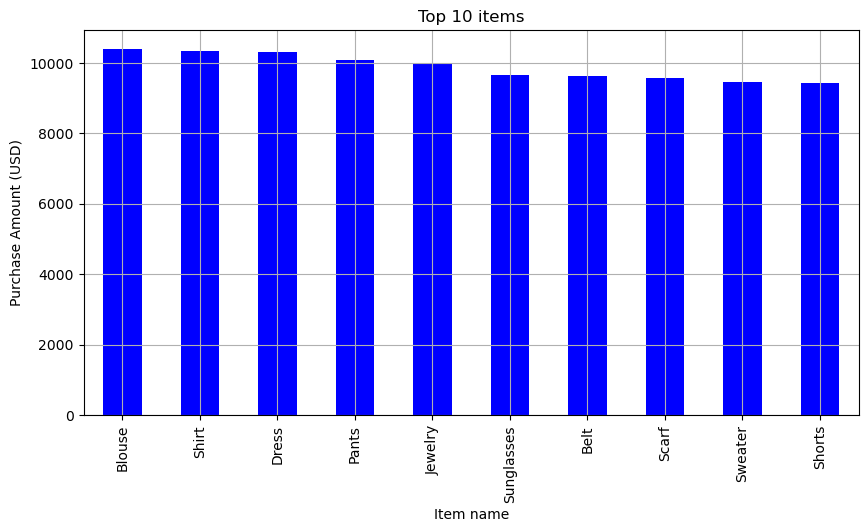

In [154]:
#Q2 What are the top 10 items purchased?
top10_purchase = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending = False).head(10)
plt.figure()
top10_purchase.plot(kind = 'bar', color='blue', grid=True, figsize=(10,5))
plt.xlabel('Item name')
plt.ylabel('Purchase Amount (USD)')
plt.title('Top 10 items')
plt.show()

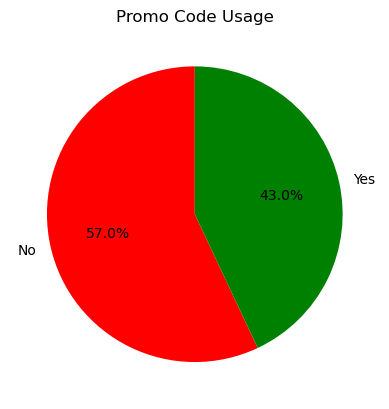

In [160]:
#Q3 How many customers use discounts?
df['Promo Code Used'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title('Promo Code Usage')
plt.ylabel('')
plt.show()

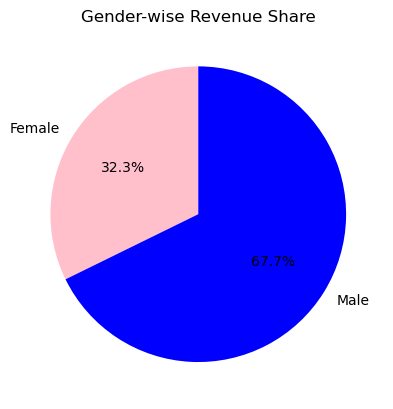

In [169]:
#Q4 Gender wise revenue contribution 
gender = df.groupby('Gender')['Purchase Amount (USD)'].sum()
gender.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['blue', 'pink'])
plt.title('Gender wise revenue')
plt.ylabel('')
plt.show()

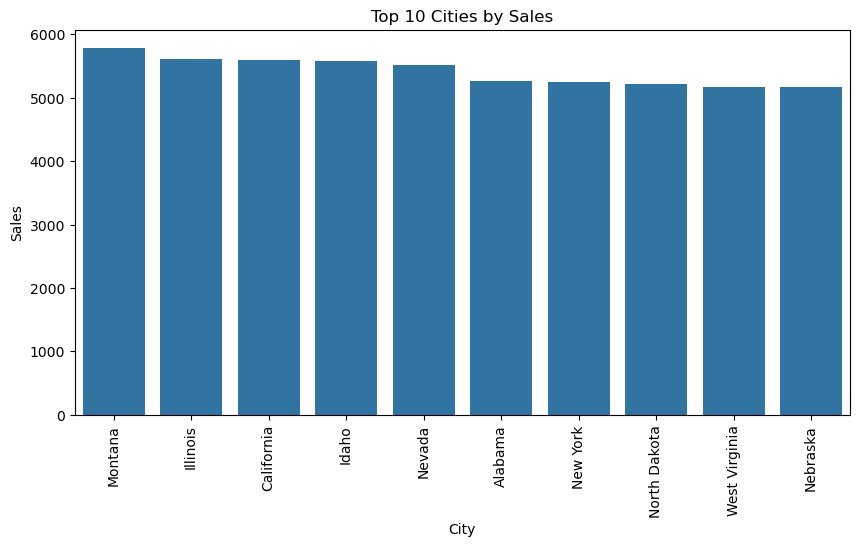

In [173]:
#Q5 Top 10 cities with highest sales

top10_cities = (df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10).reset_index())
plt.figure(figsize=(10,5))

sns.barplot(data=top10_cities, x='Location', y='Purchase Amount (USD)')

plt.xlabel('City')
plt.ylabel('Sales')
plt.title('Top 10 Cities by Sales')
plt.xticks(rotation=90)

plt.show()

In [181]:
#  Businesss insights

1. Clothing category generates most revenue as well as has highest ratings
2. Male tent to purchase more then female
3. Customers prefer free shipping
4. Customer prefer paypal payment method followed by credit card and cash
5. Surprisingly non subscribed customers generated more revenue
compared to subscribed
6. City with highest purchase is montana
7. Category with the highest average is footwear
8. Customer ID 2843 spent highest